# Plotting Isobaric Binary Phase Diagrams with `binplot`

These are a few examples of how to use Thermo-Calc TDB files to calculate isobaric binary phase diagrams. As long as the TDB file is present, each cell in these examples is self contained and can completely reproduce the figure shown.

### binplot

The phase diagrams are computed with `binplot`, which has four required arguments:
1. The `Database` object
2. A list of active components (vacancies (`VA`), which are present in many databases, must be included explictly).
3. A list of phases to consider in the calculation
4. A dictionary of conditions to consider, with keys of pycalphad `StateVariables` and values of scalars, 1D arrays, or `(start, stop, step)` ranges

Note that, at the time of writing, invariant reactions (three-phase 'regions' on binary diagrams) are not yet automatically detected so they
are not drawn on the diagram.

### TDB files

The TDB files should be located in the current working directory of the notebook. If you are running using a Jupyter notebook, the default working directory is the directory that that notebook is saved in. 

To check the working directory, run:

```python
import os
print(os.path.abspath(os.curdir))
```

TDB files can be found in the literature. The [Thermodynamic DataBase DataBase](https://avdwgroup.engin.brown.edu) (TDBDB) has indexed many available databases and links to the original papers and/or TDB files where possible.


## Al-Zn (S. Mey, 1993)

The miscibility gap in the fcc phase is included in the Al-Zn diagram, shown below.

The format for specifying a range of a state variable is (*start*, *stop*, *step*).

[S. Mey, Zeitschrift für Metallkunde 84(7) (1993) 451–455](https://doi.org/10.1515/ijmr-1993-840704).

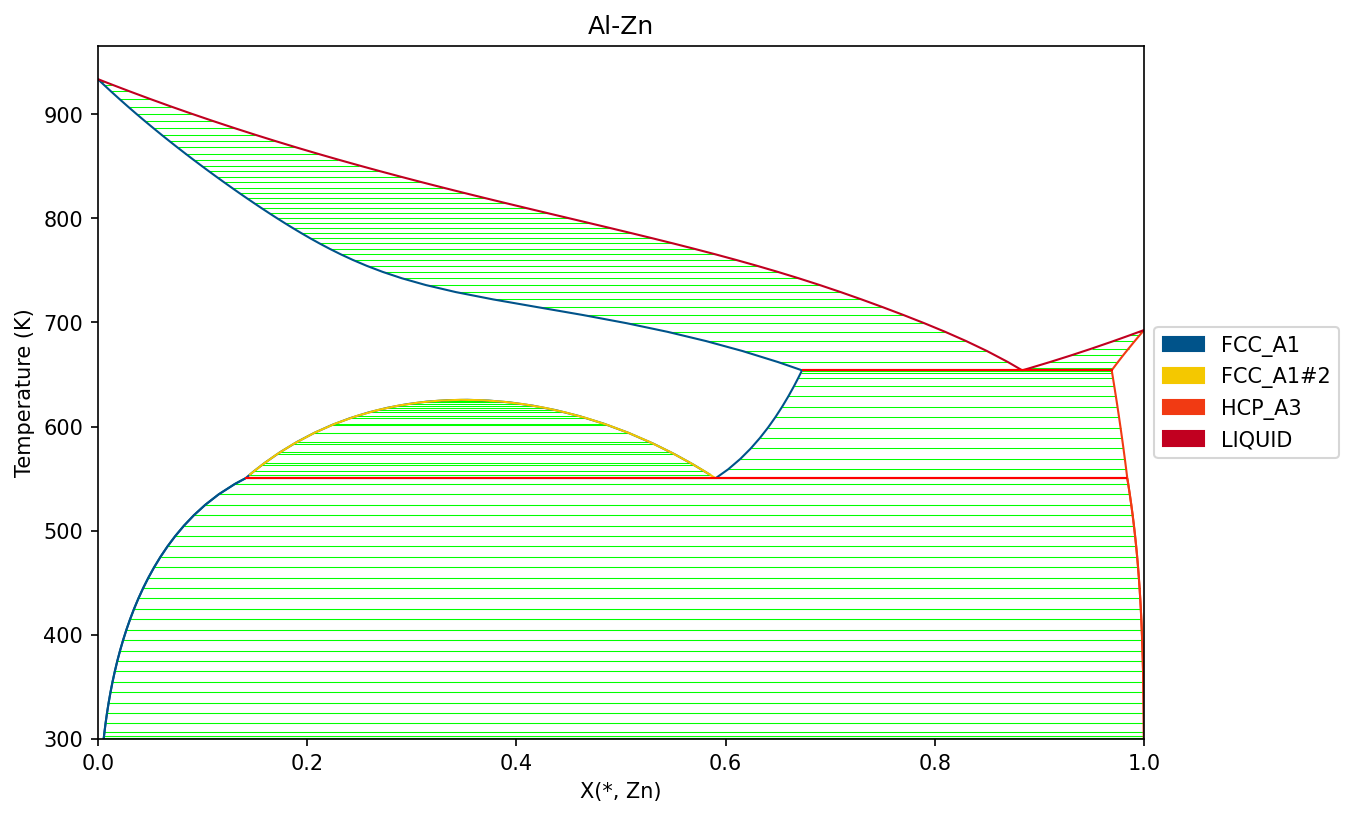

In [1]:
import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v

# Load database and choose the phases that will be considered
db_alzn = Database('databases/alzn_mey.tdb')
components = ['AL', 'ZN', 'VA']
my_phases_alzn = ['LIQUID', 'FCC_A1', 'HCP_A3']
conditions = {v.X('ZN'):(0,1,0.02), v.T: (300, 1000, 10), v.P:101325, v.N: 1}

# Create a matplotlib Figure object and get the active Axes
fig = plt.figure(figsize=(9,6),dpi=150)
axes = fig.gca()

# Compute the phase diagram and plot it on the existing axes using the `plot_kwargs={'ax': axes}` keyword argument
binplot(db_alzn, components, my_phases_alzn, conditions, plot_kwargs=dict(ax=axes))

plt.show()

## Al-Mg (Y. Zhong, 2005)

[Y. Zhong, M. Yang, Z.-K. Liu, CALPHAD 29 (2005) 303-311](https://doi.org/10.1016/j.calphad.2005.08.004)

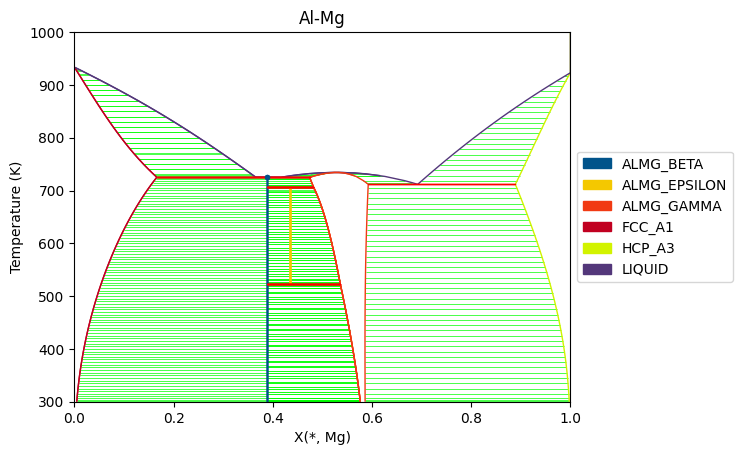

In [2]:

import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v

# Load database
dbf = Database('databases/Al-Mg_Zhong.tdb')
# Define the components
comps = ['AL', 'MG', 'VA']
# Get all possible phases programmatically
phases = dbf.phases.keys()
conditions = {v.N: 1, v.P:101325, v.T: (300, 1000, 10), v.X('MG'):(0, 1, 0.02)}

# Plot the phase diagram, if no axes are supplied, a new figure with axes will be created automatically
binplot(dbf, comps, phases, conditions)

plt.show()

## Al-Ni (Dupin, 2001)

Components and conditions can also be stored as variables and passed to binplot.

[N. Dupin, I. Ansara, B. Sundman, CALPHAD 25(2) (2001) 279-298](https://doi.org/10.1016/S0364-5916(01)00049-9)

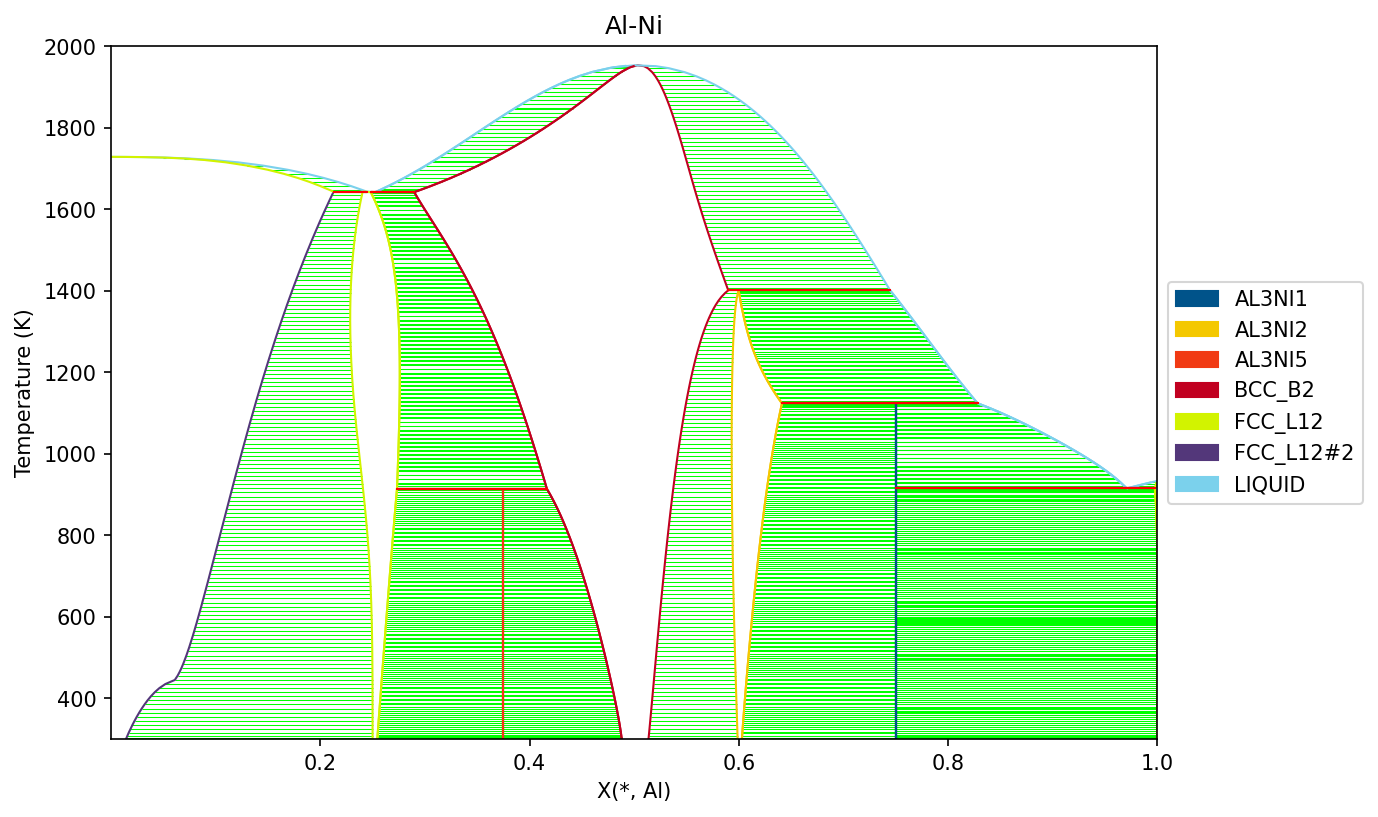

In [3]:
import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v

# Load database
dbf = Database('databases/NI_AL_DUPIN_2001.TDB')
# Set the components to consider, including vacanies (VA) explictly.
comps = ['AL', 'NI', 'VA']
# Get all the phases in the database programatically
phases = list(dbf.phases.keys())
# Create the dictionary of conditions
conditions = {
    v.N: 1, v.P: 101325,
    v.T: (300, 2000, 10),  # (start, stop, step)
    v.X('AL'): (1e-5, 1, 0.02),   # (start, stop, step)
}

# Create a matplotlib Figure object and get the active Axes
fig = plt.figure(figsize=(9,6), dpi=150)
axes = fig.gca()

# Plot by passing in all the variables
binplot(dbf, comps, phases, conditions, plot_kwargs=dict(ax=axes))

plt.show()

## Al-Fe (M. Seiersten, 1991)

Removing tielines

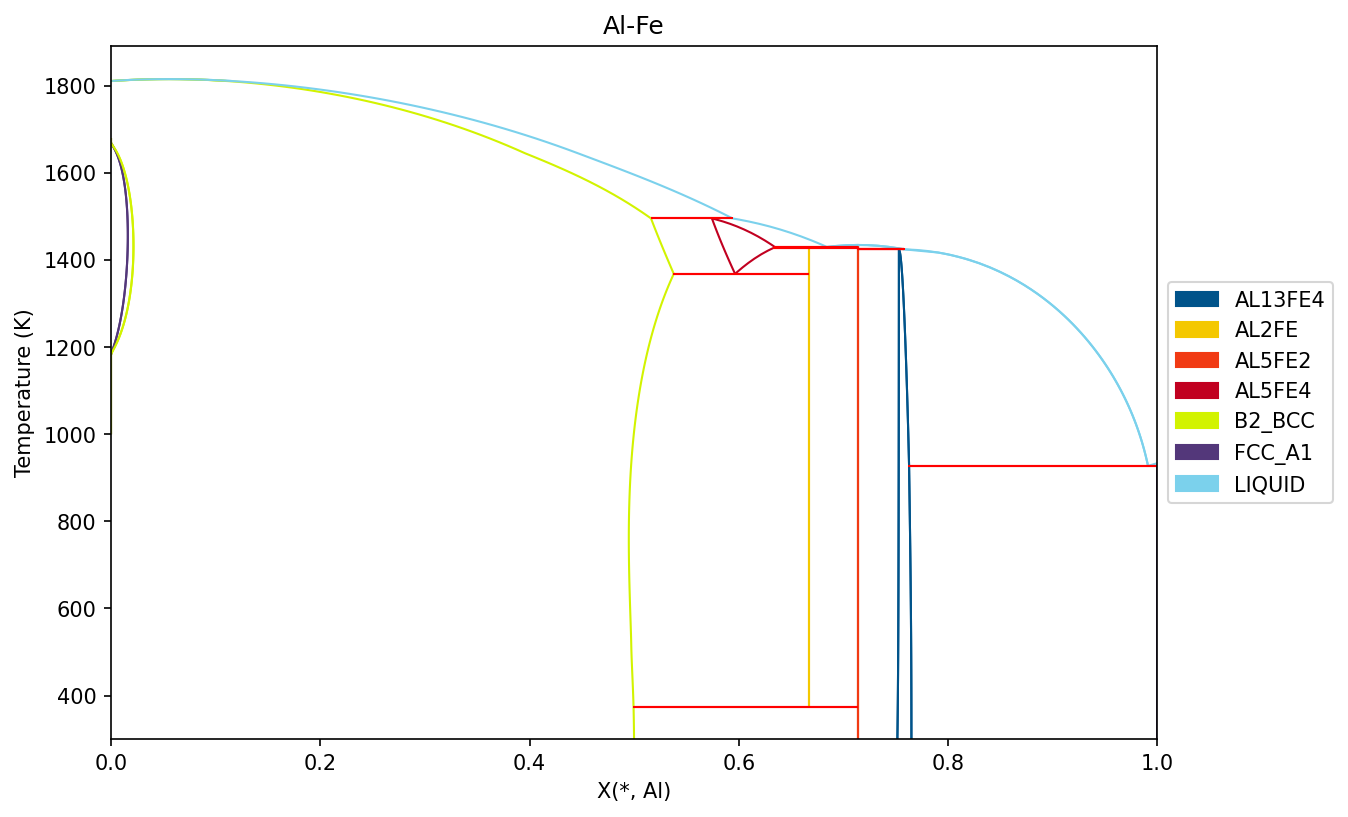

In [4]:
import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v

# Load database and choose the phases that will be considered
db_alfe = Database('databases/alfe_sei.TDB')
components = ['AL', 'FE', 'VA']
my_phases_alfe = ['LIQUID', 'B2_BCC', 'FCC_A1', 'HCP_A3', 'AL5FE2', 'AL2FE', 'AL13FE4', 'AL5FE4']
conditions = {v.X('AL'):(0,1,0.01), v.T: (300, 2000, 10), v.P:101325}

# Create a matplotlib Figure object and get the active Axes
fig = plt.figure(figsize=(9,6), dpi=150)
axes = fig.gca()

# Plot the phase diagram on the existing axes using the `plot_kwargs={'ax': axes}` keyword argument
# Tielines are turned off by including `'tielines': False` in the plotting keword argument
binplot(db_alfe, components , my_phases_alfe, conditions, plot_kwargs=dict(ax=axes, tielines=False))

plt.show()

## Nb-Re (Liu, 2013)

[X.L. Liu, C.Z. Hargather, Z.-K. Liu, CALPHAD 41 (2013) 119-127](https://doi.org/10.1016/j.calphad.2013.02.006)

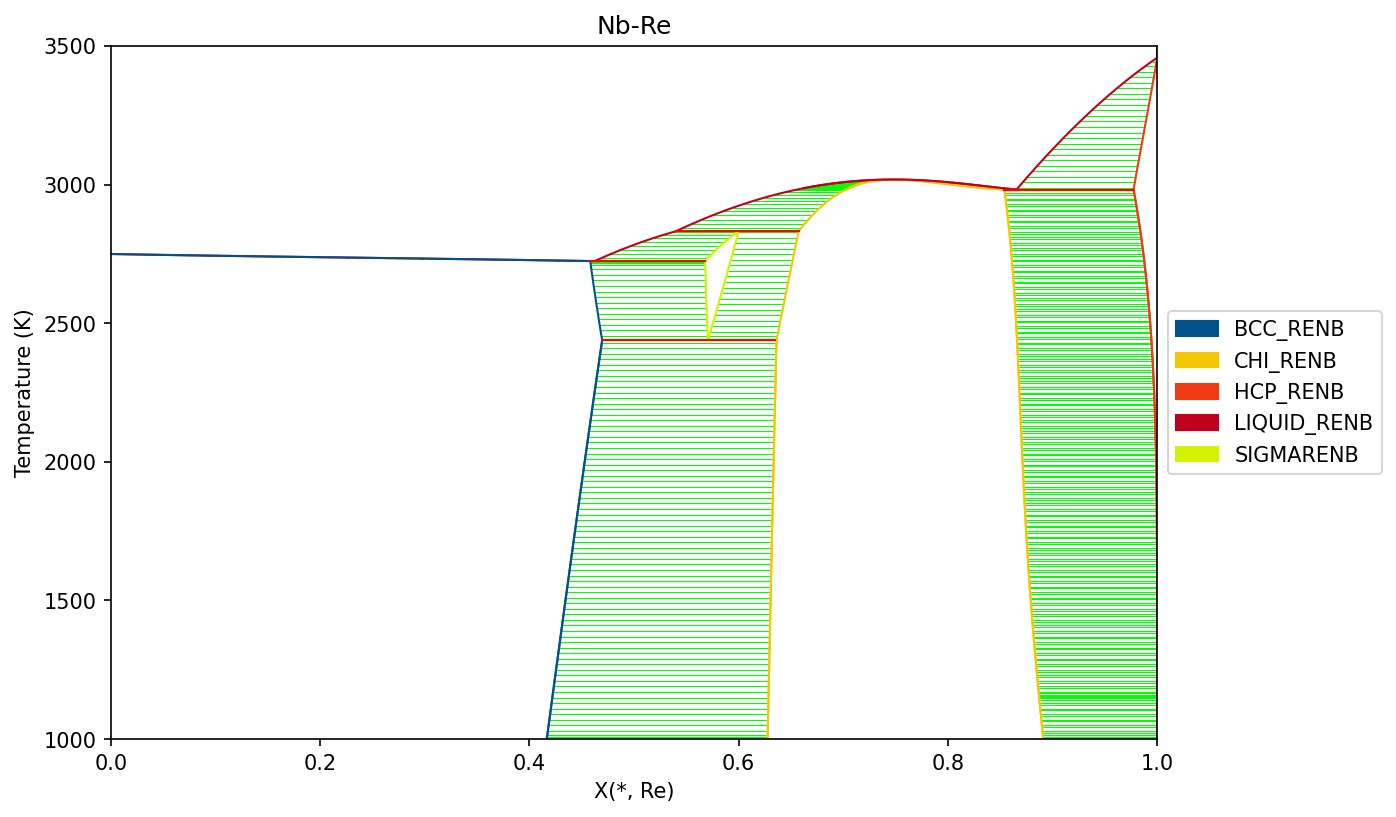

In [5]:
import matplotlib.pyplot as plt
from pycalphad import Database, binplot, variables as v

# Load database and choose the phases that will be plotted
db_nbre = Database('databases/nbre_liu.tdb')
components = ['NB', 'RE']
my_phases_nbre = ['CHI_RENB', 'SIGMARENB', 'FCC_RENB', 'LIQUID_RENB', 'BCC_RENB', 'HCP_RENB']
conditions = {v.X('RE'): (0,1,0.01), v.T: (1000, 3500, 20), v.P:101325}

# Create a matplotlib Figure object and get the active Axes
fig = plt.figure(figsize=(9,6), dpi=150)
axes = fig.gca()

# Plot the phase diagram on the existing axes using the `plot_kwargs={'ax': axes}` keyword argument
binplot(db_nbre, components , my_phases_nbre, conditions, plot_kwargs=dict(ax=axes))

axes.set_xlim(0, 1)
plt.show()

## Fe-O (L. Kjellqvist, 2010)

This model uses contains electrically charged species.
PyCalphad automatically enforces charge balance conditions.


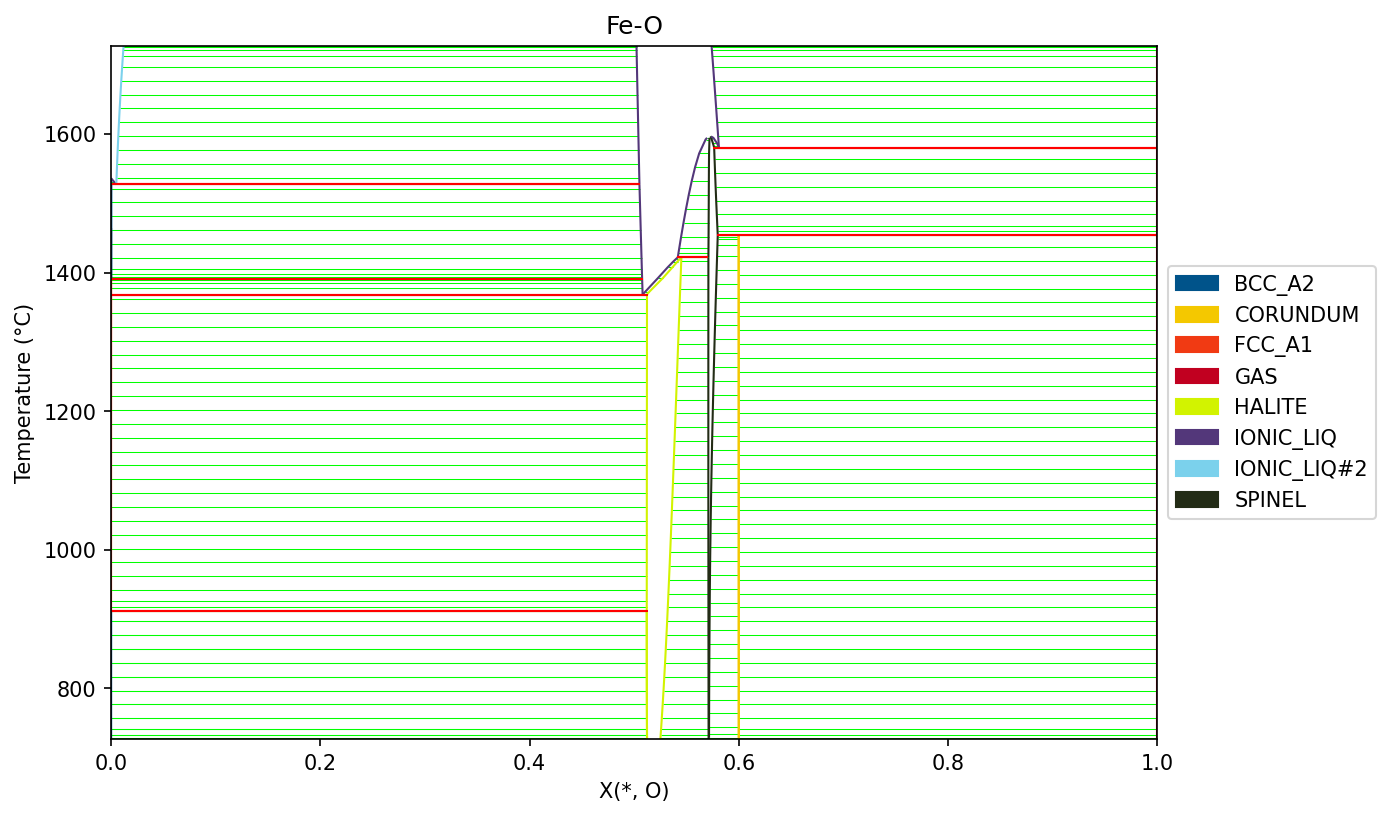

In [6]:
import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v

# Load database and choose the phases that will be considered
dbf = Database('databases/Fe-O.tdb')
components = ['FE', 'O', 'VA']
phases = sorted(dbf.phases.keys())
conditions = {v.X('O'):(0,10.8,0.05), v.T: (1000, 2000, 20), v.P:101325, v.N: 1}

# Create a matplotlib Figure object and get the active Axes
fig = plt.figure(figsize=(9,6), dpi=150)
axes = fig.gca()

# Compute the phase diagram and plot it on the existing axes in Celsius
binplot(dbf, components, phases, conditions, plot_kwargs=dict(ax=axes, y=v.T["degC"]))

plt.show()

# Plotting Ternary Phase Diagrams and Using Triangular Axes

The `ternplot` API provides a straightforward way to calculate equilibria and generate ternary phase diagrams. Alternatively, if you already have an equilibrium calculation, you can directly import and use `eqplot`.

## ternplot

Here we will use the `ternplot` API to plot an isothermal section of the Cr-Fe-Nb system from the thermodynamic database found at [Liquidus projection and thermodynamic modeling of the Cr-Fe-Nb ternary system by Jacob et al., Calphad 54 (2016) 1-15](https://doi.org/10.1016/j.calphad.2016.04.013)

Wall Time (Total elapsed): 20 s


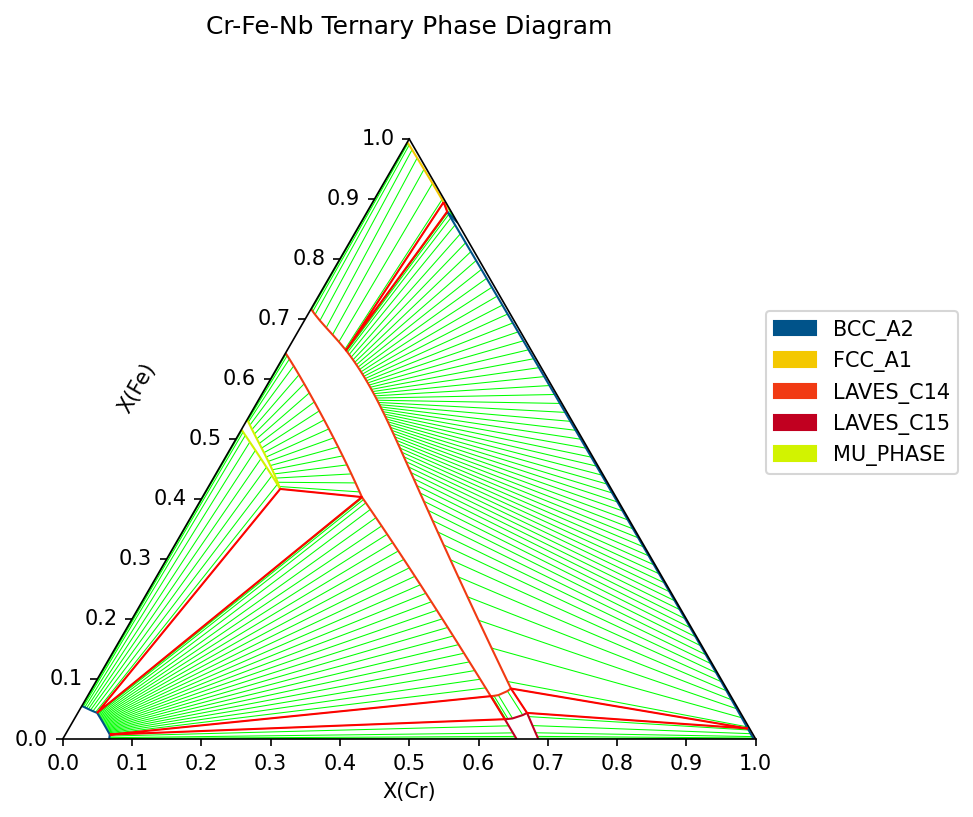

In [7]:
import time
import matplotlib.pyplot as plt
from pycalphad import Database, ternplot
from pycalphad import variables as v

db_cr_fe_nb = Database('databases/CrFeNb_Jacob2016.tdb')
comps = ['CR', 'FE', 'NB', 'VA']
phases = list(db_cr_fe_nb.phases.keys())
conds = {v.T: 1323, v.P:101325, v.X('CR'): (0,1,0.015), v.X('FE'): (0,1,0.015)}

start_time = time.perf_counter()

ax = ternplot(db_cr_fe_nb, comps, phases, conds, x=v.X('CR'), y=v.X('FE'))
fig = ax.figure
ax.set_title("Cr-Fe-Nb Ternary Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)

end_time = time.perf_counter()

print(f"Wall Time (Total elapsed): {round(end_time - start_time)} s")


Here is another example for plotting the isothermal section of the Al-Cu-Y system from the thermodynamic database found at the [NIST CALPHAD assessments](http://hdl.handle.net/11115/101) assessed [by Zhang et al. in Thermodynamic description of the Al–Cu–Y ternary system  (Calphad 35 (2011))](https://doi.org/10.1016/j.calphad.2011.09.008). Labels for phases in the three-phase equilibria can be added for clarity.

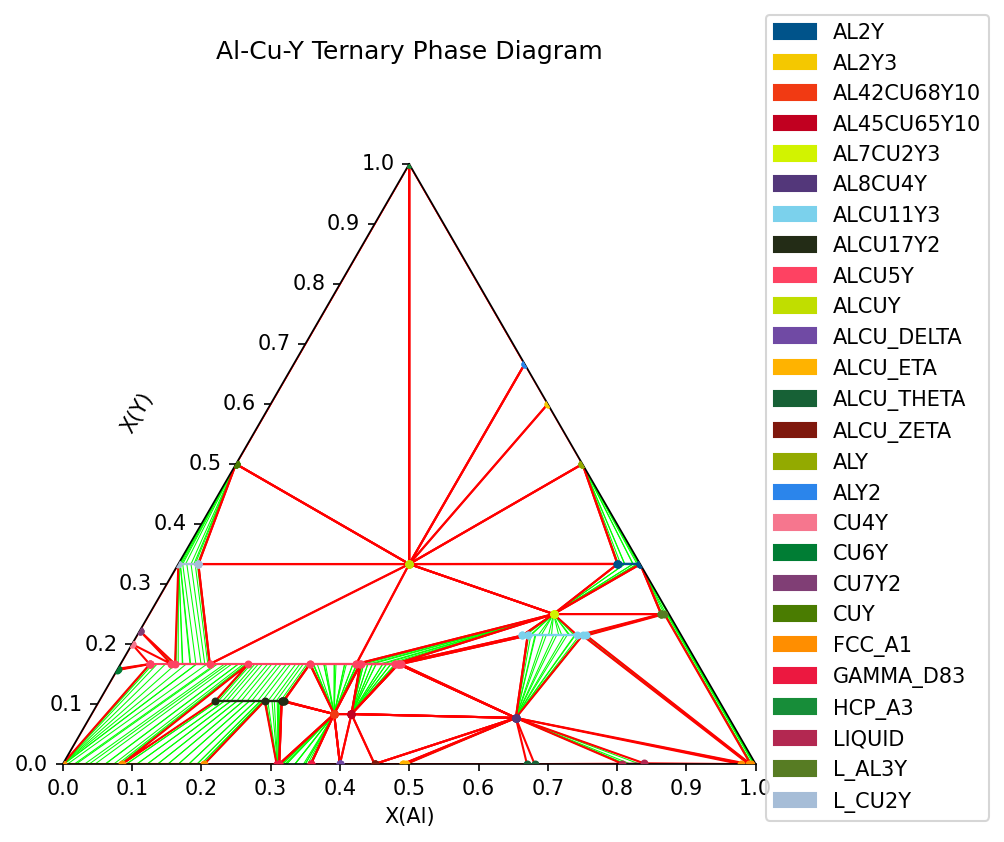

In [8]:
db_al_cu_y = Database('databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
phases = list(db_al_cu_y.phases.keys())
conds = {v.T: 830, v.P:101325, v.X('AL'): (0,1,0.015), v.X('Y'): (0,1,0.015)}

ax = ternplot(db_al_cu_y, comps, phases, conds, x=v.X('AL'), y=v.X('Y'), label_nodes=True)
fig = ax.figure
ax.set_title("Al-Cu-Y Ternary Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)

By default, the mapping code will attempt to generate a list of starting points by searching around the axes of the phase diagram. However, in some cases, phase regions in the phase diagram will not connect to the axis. This is the case if we want to plot the Al-Cu-Y ternary at higher temperatures (e.g. >1360 K). The following will show how to use the mapping API to add custom starting points to generate the correct phase diagram.

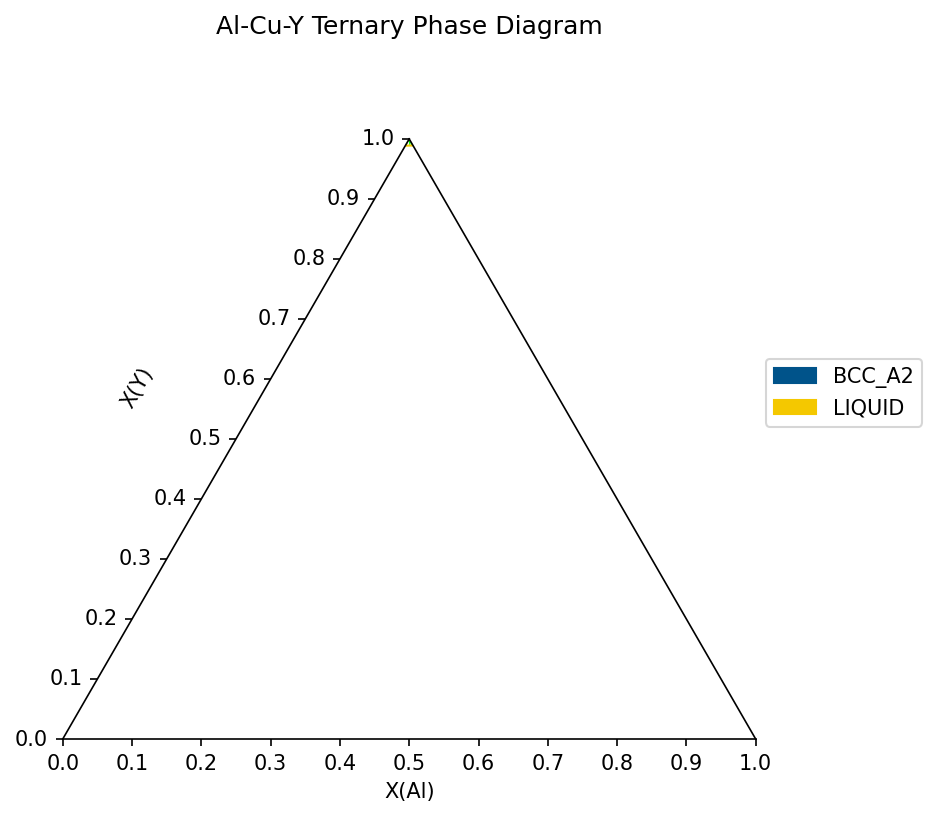

In [9]:
from pycalphad.mapping import TernaryStrategy, plot_ternary

db_al_cu_y = Database('databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
phases = list(db_al_cu_y.phases.keys())
conds = {v.T: 1770, v.P:101325, v.X('AL'): (0,1,0.015), v.X('Y'): (0,1,0.015)}
strat = TernaryStrategy(db_al_cu_y, comps, phases, conds)

# Add automatic starting points by searching along the axes
strat.generate_automatic_starting_points()

strat.do_map()

ax = plot_ternary(strat, x=v.X('AL'), y=v.X('Y'), label_nodes=True)
fig = ax.figure
ax.set_title("Al-Cu-Y Ternary Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)

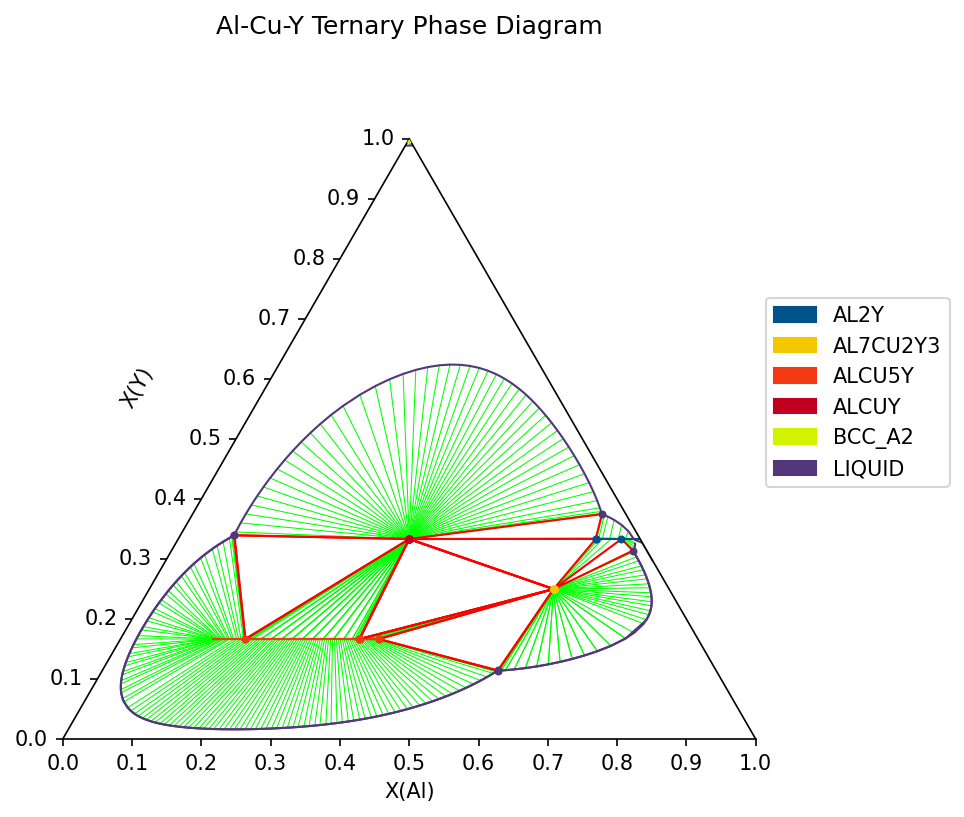

In [10]:
from pycalphad.mapping import TernaryStrategy, plot_ternary

db_al_cu_y = Database('databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
phases = list(db_al_cu_y.phases.keys())
conds = {v.T: 1770, v.P:101325, v.X('AL'): (0,1,0.015), v.X('Y'): (0,1,0.015)}
strat = TernaryStrategy(db_al_cu_y, comps, phases, conds)

# Add automatic starting points by searching along the axes
strat.generate_automatic_starting_points()

# Add custom starting point near middle of phase diagram
strat.add_nodes_from_conditions({v.T: 1770, v.P: 101325, v.X('AL'): 0.35, v.X('Y'): 0.3})
strat.do_map()

ax = plot_ternary(strat, x=v.X('AL'), y=v.X('Y'), label_nodes=True)
fig = ax.figure
ax.set_title("Al-Cu-Y Ternary Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)

## ChemSage `.dat` databases and the modified quasichemical model

All examples above load TDB files, but PyCalphad's `Database` also reads ChemSage `.dat` files. ChemSage `.dat` files can contain phases that use the **modified quasichemical model in the quadruplet approximation (MQMQA)**, which represents short-range ordering in ionic liquids (slags, molten salts) with pairs or quadruplet species.

Below we load the Fe-Sb-O-S slag database ([D. Shishin, T. Hidayat, J. Chen, P. Hayes, E. Jak, CALPHAD 65 (2019) 16-24](https://doi.org/10.1016/j.calphad.2019.01.016)) containing a MQMQA model for slag. All other PyCalphad code works identically.



Phases: ['FE', 'FE2O3', 'FEO', 'O', 'S', 'SB', 'SB2O3', 'SB2S3', 'SLAG-LIQ']
SLAG-LIQ uses the modified quasichemical model (SUBQ)
  cations: [Species('FE2++2.0', 'FE2.0', charge=2.0), Species('FE3++3.0', 'FE3.0', charge=3.0), Species('SB3++3.0', 'SB3.0', charge=3.0)]
  anions:  [Species('O-2.0', 'O1.0', charge=-2.0), Species('S-2.0', 'S1.0', charge=-2.0)]


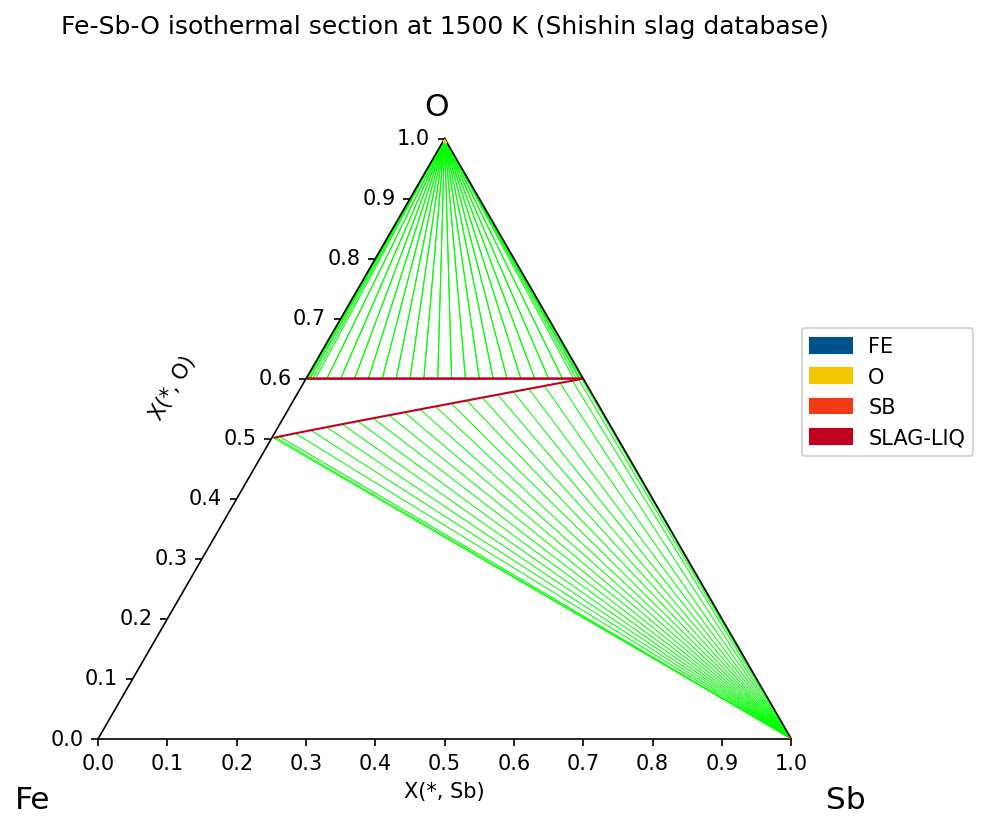

In [11]:
from importlib.resources import files
import pycalphad.tests.databases
from pycalphad import Database, ternplot, variables as v

dbf = Database(files(pycalphad.tests.databases) / "Shishin_Fe-Sb-O-S_slag.dat")
print('Phases:', sorted(dbf.phases.keys()))

# Identify phases that use the modified quasichemical model
for phase_name in sorted(dbf.phases.keys()):
    hints = dbf.phases[phase_name].model_hints
    if 'mqmqa' in hints:
        cations = list(hints['mqmqa']['chemical_groups']['cations'].keys())
        anions = list(hints['mqmqa']['chemical_groups']['anions'].keys())
        print(f"{phase_name} uses the modified quasichemical model ({hints['mqmqa']['type']})")
        print(f"  cations: {cations}")
        print(f"  anions:  {anions}")

comps = ['FE', 'SB', 'O', 'VA']
phases = list(dbf.phases.keys())
conditions = {v.P: 101325, v.T: 1500, v.X('O'): (0, 1, 0.02), v.X('SB'): (0, 1, 0.02)}

ax = ternplot(dbf, comps, phases, conditions)
ax.text(-0.12, -0.10, 'Fe', size=15, transform=ax.transAxes)
ax.text(0.47, 0.90,  'O',  size=15, transform=ax.transAxes)
ax.text(1.05, -0.10, 'Sb', size=15, transform=ax.transAxes)
ax.set_title('Fe-Sb-O isothermal section at 1500 K (Shishin slag database)')
fig = ax.figure
fig.set_size_inches(9, 6)
fig.set_dpi(150)

# Plotting using the Mapping API

`Mapping` uses the algorithms outlined in [**Algorithms useful for calculating multi-component equilibria, phase diagrams and other kinds of diagrams** (B. Sundman, N. Dupin, B. Hallstedt, Calphad 75 (2021) 102330)](https://doi.org/10.1016/j.calphad.2021.102330) to construct phase diagrams by stepping along phase boundaries.

`binplot` and `ternplot` are thin wrappers around the binary and ternary mapping strategies; however, additional plotting capabilities are available through the `mapping` module.

## Binary phase diagrams with mapping

This shows how to plot a binary phase diagram through mapping as an alternative to binplot.

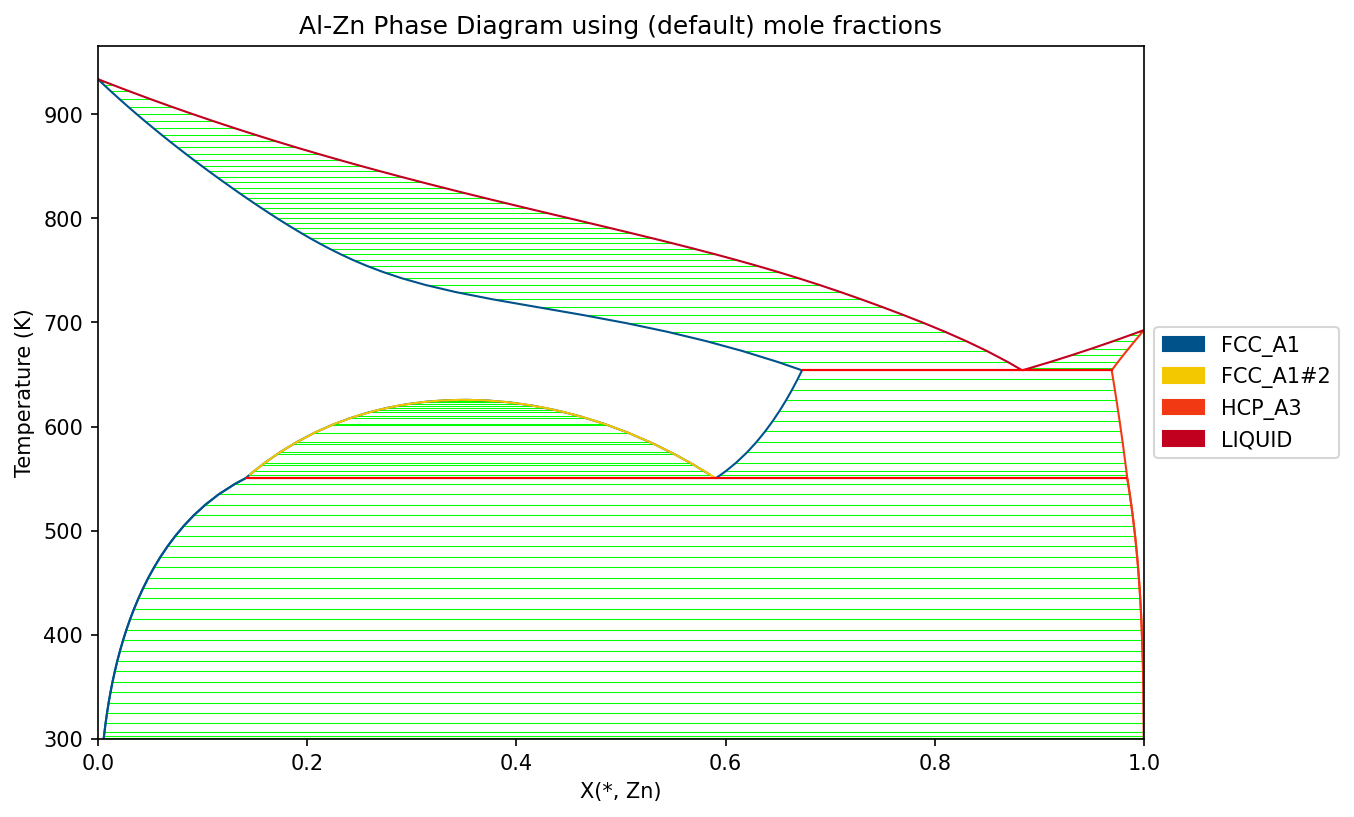

In [12]:
from pycalphad import Database, variables as v
from pycalphad.mapping import BinaryStrategy, plot_binary
import matplotlib.pyplot as plt

dbf = Database('databases/alzn_mey.tdb')
comps = ['AL', 'ZN', 'VA']
conds = {v.N: 1, v.P:101325, v.T: (300, 1000, 10), v.X('ZN'):(0, 1, 0.02)}

# Phases will be automatically filtered with components if no phases are passed
binary = BinaryStrategy(dbf, comps, phases=None, conditions=conds)
binary.do_map()
ax = plot_binary(binary)
fig = ax.figure
ax.set_title("Al-Zn Phase Diagram using (default) mole fractions")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

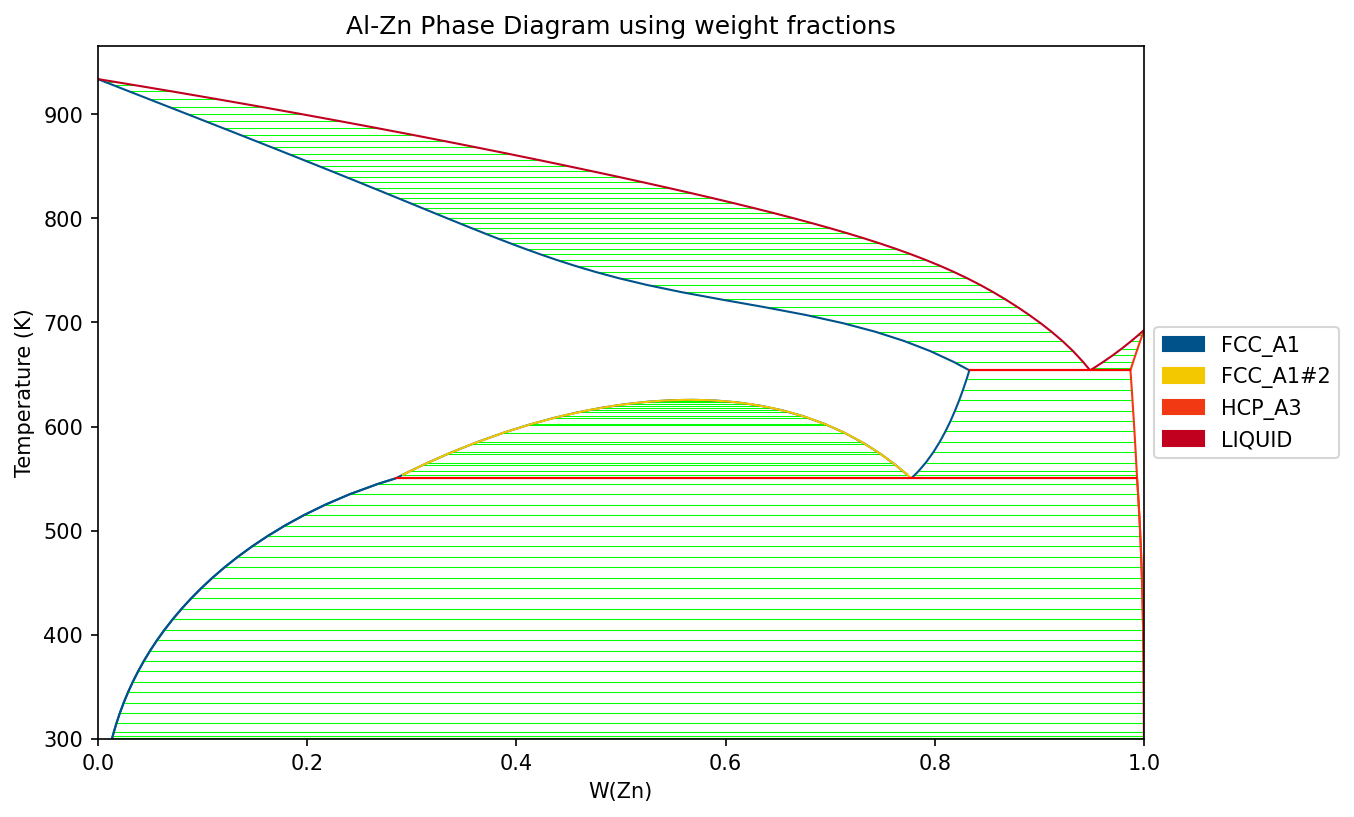

In [13]:
# Plotting in weight fraction
ax = plot_binary(binary, v.W('ZN'), v.T)
fig = ax.figure
ax.set_xlim([0, 1])
ax.set_title("Al-Zn Phase Diagram using weight fractions")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

Similarly, the same can be done for ternaries using TernaryStrategy and plot_ternary.

## Step plotting

Step mapping allows computing equilibrium along a single axis. By default, step plotting will plot phase fraction vs. variable axis, but this can be modified through plotting.

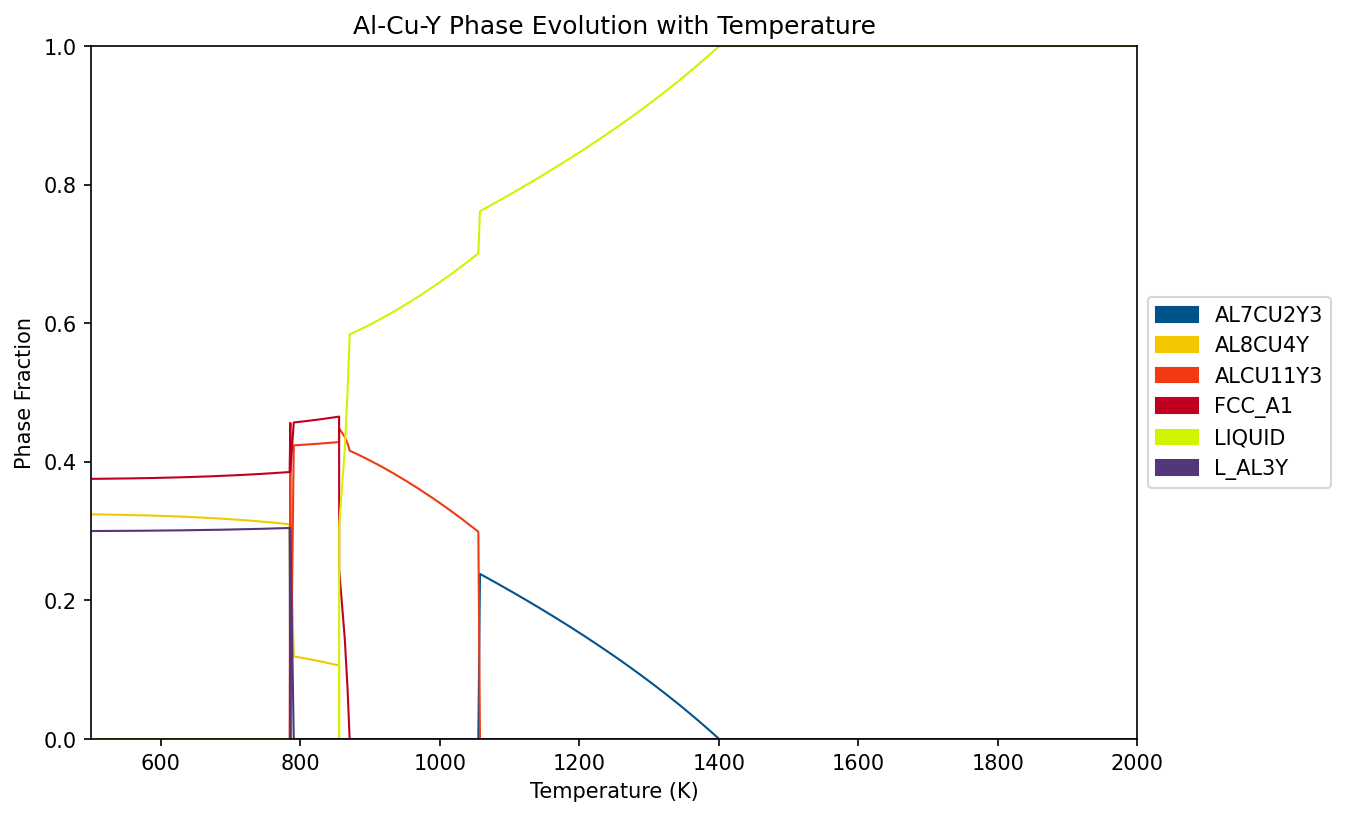

In [14]:
from pycalphad.mapping import StepStrategy, plot_step

dbf = Database('databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
conds = {v.T: (500, 2000, 10), v.X('AL'): 0.8, v.X('CU'): 0.1, v.P: 101325, v.N: 1}

step = StepStrategy(dbf, comps, phases=None, conditions=conds)
step.do_map()

ax = plot_step(step)
fig = ax.figure
ax.set_title("Al-Cu-Y Phase Evolution with Temperature")
ax.set_xlim(500, 2000)
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

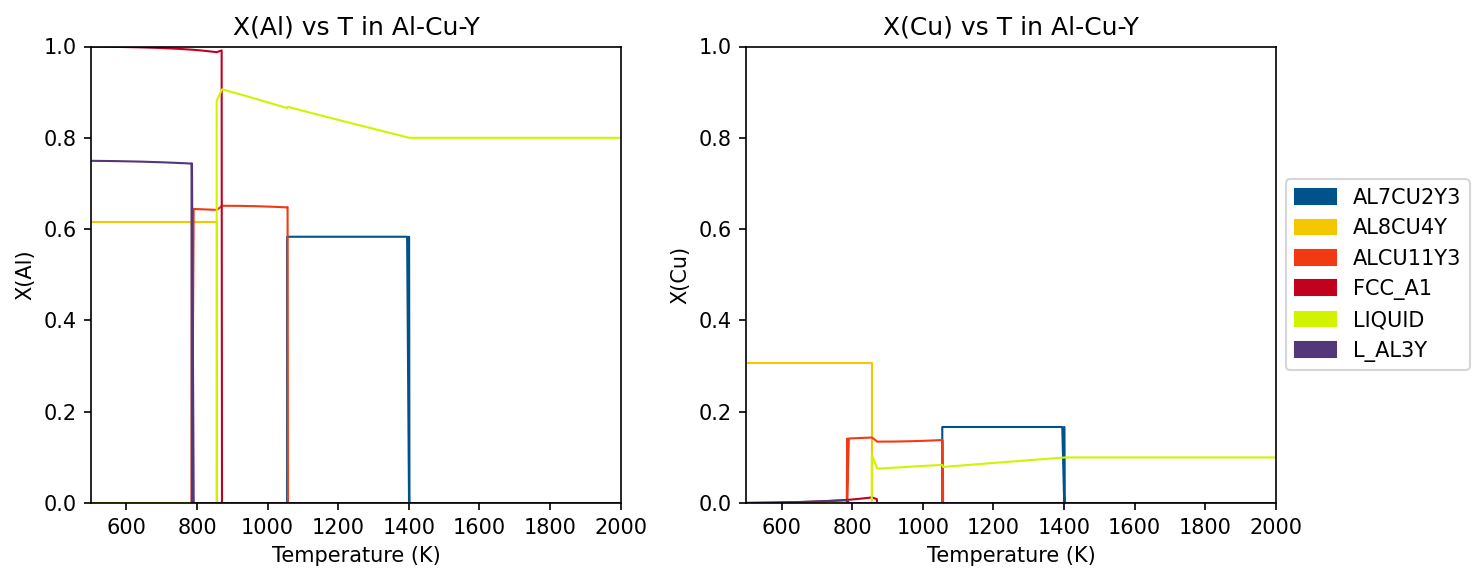

In [15]:
# Plotting composition of Al and Cu in each phase
fig, ax = plt.subplots(1, 2, figsize=(10,4))
plot_step(step, x=v.T, y=v.X('AL'), ax=ax[0])
plot_step(step, x=v.T, y=v.X('CU'), ax=ax[1])

ax[0].set_title("X(Al) vs T in Al-Cu-Y")
ax[0].set_xlim([500, 2000])
ax[0].set_ylim([0, 1])
ax[0].get_legend().remove()

ax[1].set_title("X(Cu) vs T in Al-Cu-Y")
ax[1].set_xlim([500, 2000])
ax[1].set_ylim([0, 1])
fig.tight_layout()
fig.set_dpi(150)
plt.show()

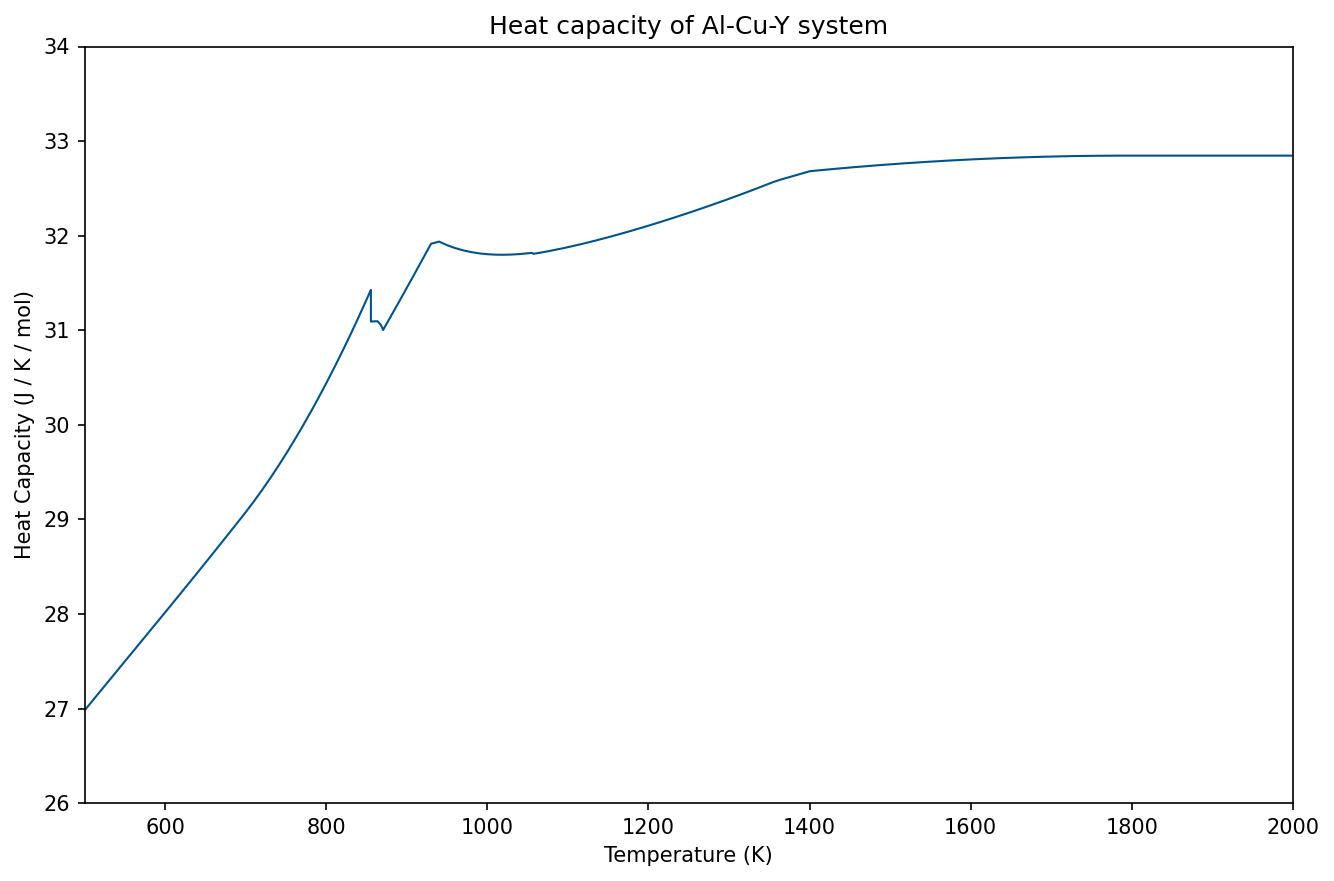

In [16]:
# Plotting heat capacity vs T
fig, ax = plt.subplots(figsize=(9,6))
plot_step(step, x=v.T, y='CPM', ax=ax)
ax.set_title("Heat capacity of Al-Cu-Y system")
ax.set_xlim([500, 2000])
ax.set_ylim([26, 34])
fig.tight_layout()

fig.set_dpi(150)
plt.show()

## Isopleth plotting

For multicomponent systems, isopleths can be computed and plotted.

/Users/brandonbocklund/src/2026-calphad-workshop/.venv/lib/python3.13/site-packages/pycalphad/core/conditions.py:116: UserWarning: Some specified compositions are below the minimum allowed composition of 1e-10.
  warnings.warn(


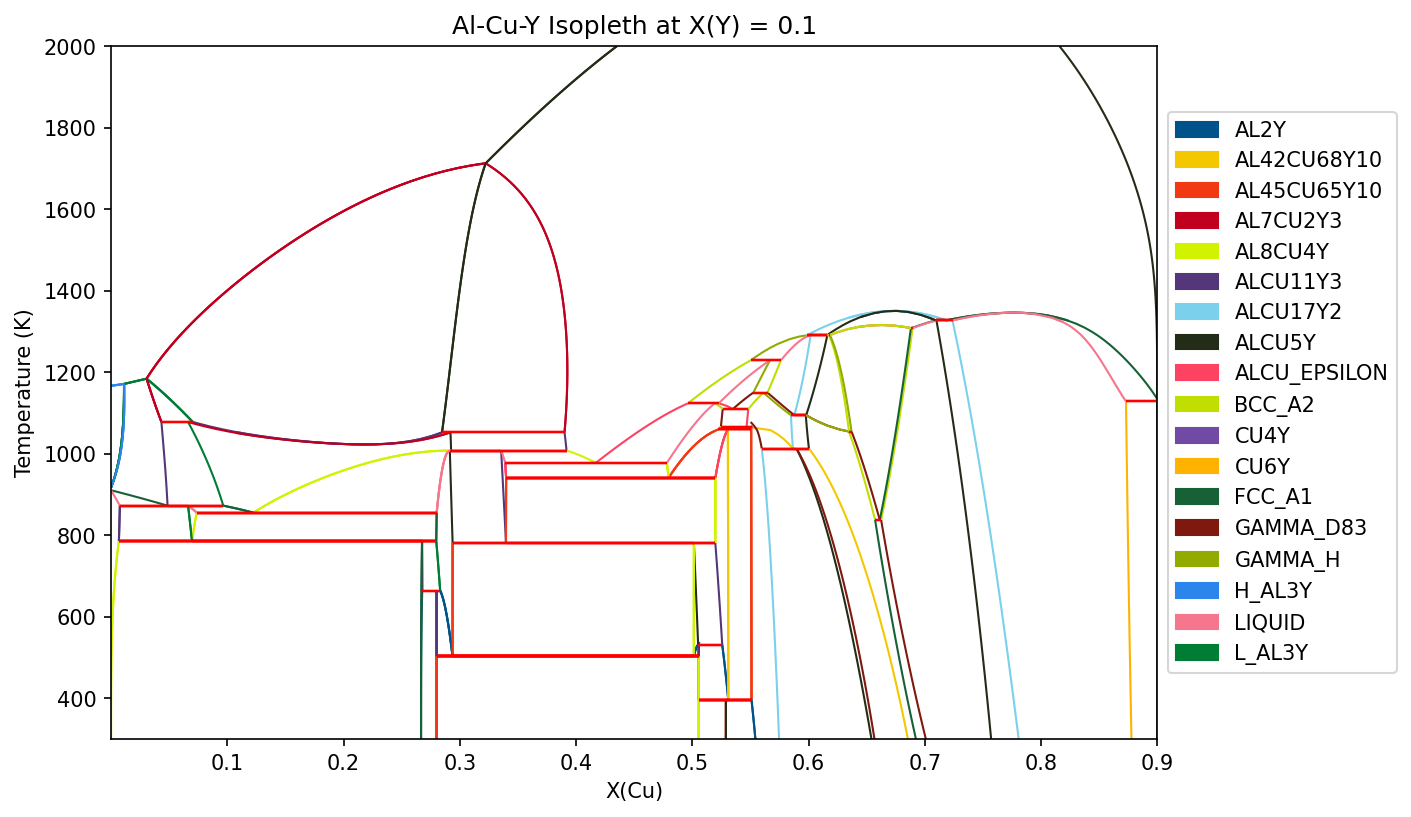

In [17]:
from pycalphad.mapping import IsoplethStrategy, plot_isopleth

dbf = Database('databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
conds = {v.T: (300, 2000, 10), v.P: 101325, v.N: 1, v.X('Y'): 0.1, v.X('CU'): (0, 1, 0.01)}

iso = IsoplethStrategy(dbf, comps, phases=None, conditions=conds)
iso.do_map()
ax = plot_isopleth(iso)
fig = ax.figure
ax.set_title("Al-Cu-Y Isopleth at X(Y) = 0.1")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

## Custom plotting

While the Mapping API provides built-in plotting functions, access to Mapping data is provided to build custom plotting functions. Below is an example to plot binary and ternary phase diagrams with shaded regions.

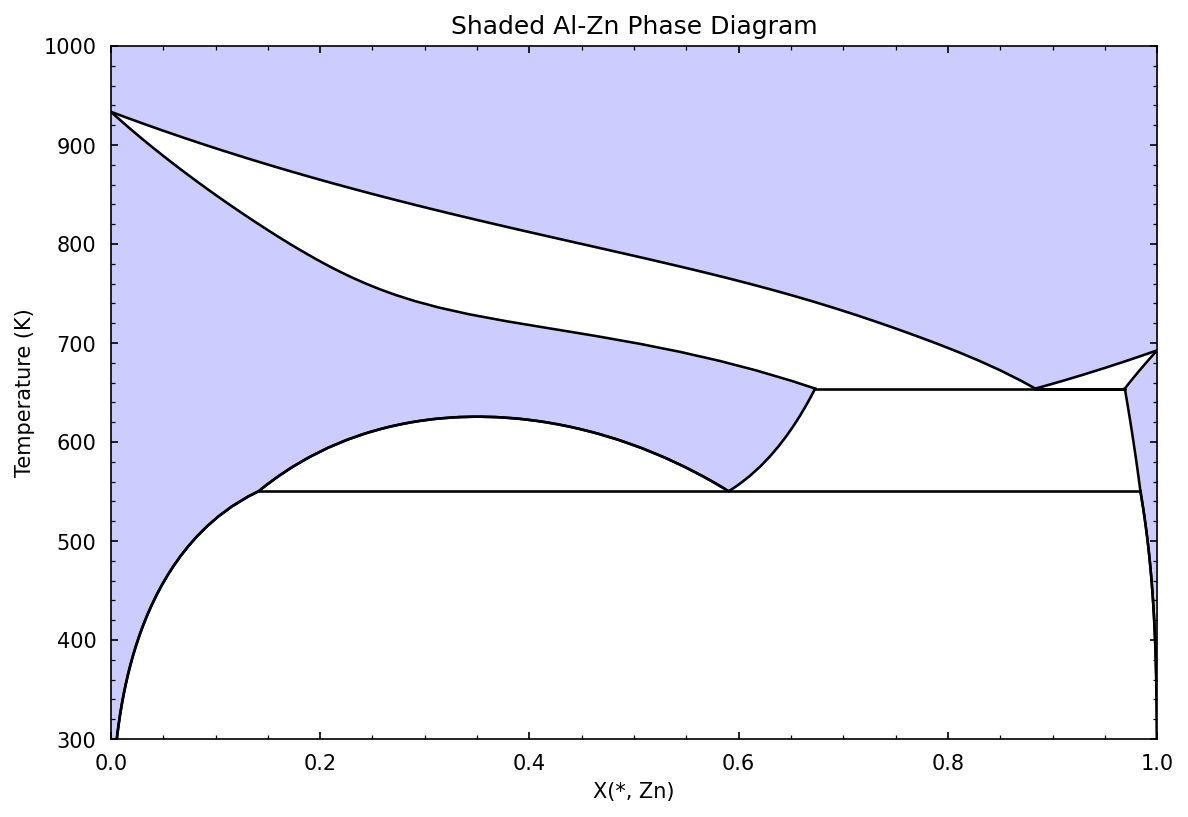

In [18]:
import numpy as np
from pycalphad.mapping.plotting import get_label

def plot_shaded_binary(strategy: BinaryStrategy, ax, single_phase_color = (0.8, 0.8, 1.0), two_phase_color = (1.0, 1.0, 1.0)):
    # Assume x is composition and y is temperature or pressure
    x = [var for var in strategy.axis_vars if var not in [v.N, v.P, v.T]][0]
    y = [var for var in strategy.axis_vars if var in [v.N, v.P, v.T]][0]

    # Anything that the tielines or invariants do not cover is single phase, so we can plot the entire region with the single phase color and add on top of it
    ax.fill_between(strategy.axis_lims[x], [strategy.axis_lims[y][0], strategy.axis_lims[y][0]], [strategy.axis_lims[y][1], strategy.axis_lims[y][1]], color=single_phase_color)

    # Plot invariant data. These are lines in a binary phase diagram, so we just have to plot as such
    inv_data = strategy.get_invariant_data(x, y)
    for inv in inv_data:
        ax.plot(inv.x, inv.y, color='k', linewidth=1.25, linestyle='-')

    # Plot tieline data. Each tieline has x,y for both phases, so we plot those as lines, then fill in between
    tie_data = strategy.get_tieline_data(x, y)
    for tie in tie_data:
        for ph, xp, yp in zip(tie.phases, tie.x, tie.y):
            ax.plot(xp, yp, color='k', linewidth=1.25, linestyle='-')
        ax.fill_betweenx(tie.y[0], tie.x[0], tie.x[1], color=two_phase_color)

    # Axis labels and limits
    ax.set_xlabel(get_label(x))
    ax.set_xlim(strategy.axis_lims[x])
    ax.set_ylabel(get_label(y))
    ax.set_ylim(strategy.axis_lims[y])

    # Add major and minor axis ticks on inside of plot
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in', bottom=True, top=True, left=True, right=True, pad=7)
    ax.tick_params(axis='both', which='major', direction='in', bottom=True, top=True, left=True, right=True, pad=7)

dbf = Database('databases/alzn_mey.tdb')
comps = ['AL', 'ZN', 'VA']
conds = {v.N: 1, v.P:101325, v.T: (300, 1000, 10), v.X('ZN'):(0, 1, 0.02)}

# Phases will be automatically filtered with components if no phases are passed
binary = BinaryStrategy(dbf, comps, phases=None, conditions=conds)
binary.do_map()
fig, ax = plt.subplots()
plot_shaded_binary(binary, ax)
ax.set_title("Shaded Al-Zn Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

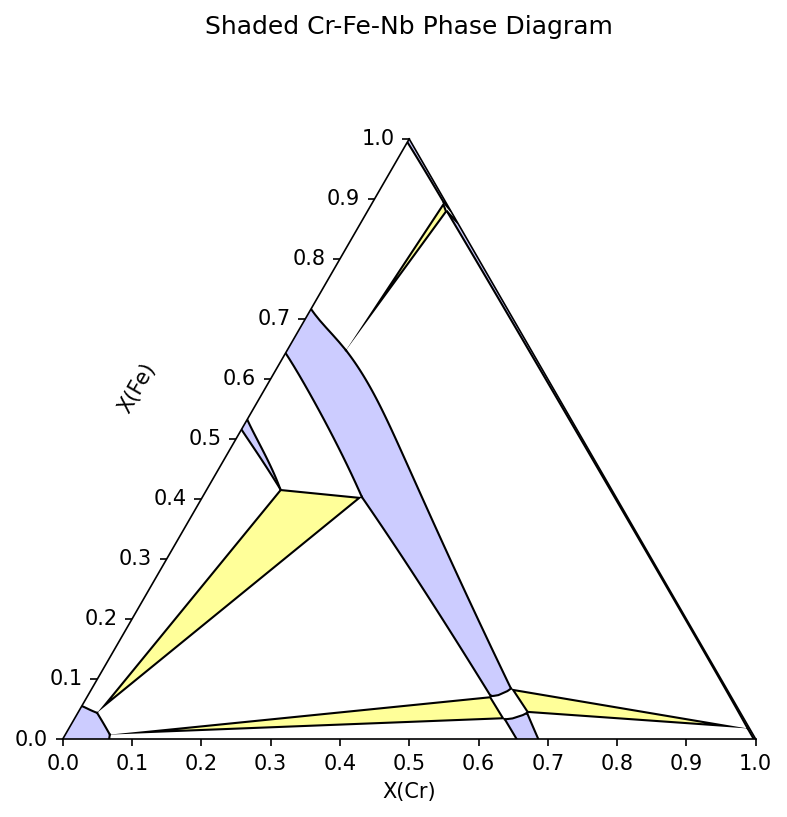

In [19]:
import matplotlib.patches as mp
from pycalphad.plot import triangular
from pycalphad.mapping import TernaryStrategy

def plot_shaded_ternary(strategy: TernaryStrategy, ax, x = None, y = None, single_phase_color = (0.8, 0.8, 1.0), two_phase_color = (1.0, 1.0, 1.0), three_phase_color = (1.0, 1.0, 0.6)):
    if x is None:
        x = strategy.axis_vars[0]
    if y is None:
        y = strategy.axis_vars[1]

    # Fill plot with single phase color since anything that the tieline and invariants do not cover is single phase
    ax.fill_between([0, 1], [0, 0], [1, 1], color=single_phase_color)

    # Plot invariant data. These are triangles, so we can add them as matplotlib patches
    inv_data = strategy.get_invariant_data(x, y)
    for inv in inv_data:
        triangle = mp.Polygon(np.array([inv.x, inv.y]).T, facecolor=three_phase_color, edgecolor='k', linewidth=2, joinstyle='bevel')
        ax.add_patch(triangle)

    # Plot tieline data. As with invariant data, we can add these as matplotlib patches
    # Depending on the starting points during mapping, a two-phase region can be split, so we
    # plot the patch without an outline, then plot the x, y data as a line afterwards
    tie_data = strategy.get_tieline_data(x, y)
    for tie in tie_data:
        xp = np.concatenate([tie.x[0], tie.x[1][::-1]])
        yp = np.concatenate([tie.y[0], tie.y[1][::-1]])
        polygon = mp.Polygon(np.array([xp, yp]).T, facecolor=two_phase_color)
        ax.add_patch(polygon)
        for i in range(len(tie.x)):
            ax.plot(tie.x[i], tie.y[i], color='k', linewidth=1)

    # Axis labels and limits
    ax.set_ylabel(get_label(y))
    ax.set_xlabel(get_label(x))
    ax.yaxis.label.set_rotation(60)
    ax.yaxis.set_label_coords(x=0.12, y=0.5)

dbf = Database('databases/CrFeNb_Jacob2016.tdb')
comps = ['CR', 'FE', 'NB', 'VA']
phases = list(dbf.phases.keys())
conds = {v.T: 1323, v.P:101325, v.X('CR'): (0,1,0.015), v.X('FE'): (0,1,0.015)}

tern = TernaryStrategy(dbf, comps, phases, conds)
tern.do_map()
fig, ax = plt.subplots(subplot_kw={'projection': 'triangular'})
plot_shaded_ternary(tern, ax, v.X('CR'), v.X('FE'))
ax.set_title("Shaded Cr-Fe-Nb Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()